# CDF of |Entropy Change| by Context Length

Two plots (qa_1, qa_2). Each shows `|H_t - H_{t-1}|` curves for all lengths + per-length shuffled baseline.  
Each curve is annotated with teacher-forced PPL computed on the same inputs.

In [1]:
import json
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

os.environ.setdefault('MPLCONFIGDIR', '/tmp/mplconfig')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)
plt.rcParams['axes.grid'] = True

In [14]:
# ===== Config =====
MODEL_NAME  = 'meta-llama/Llama-3.1-8B'
DEVICE      = 'cuda:0'
DTYPE       = torch.bfloat16

BASE_DIR    = Path('/c2/jenny/r3/RULER_outputs/llama3.1-8b-chat/synthetic')
LENGTHS     = [4096, 8192, 16384, 32768, 65536, 131072]
TASKS       = ['qa_1', 'qa_2']
TEXT_KEY    = 'input'

# Fewer samples at longer lengths to keep runtime manageable
N_SAMPLES   = {4096: 50, 8192: 50, 16384: 30, 32768: 20, 65536: 10, 131072: 5}
MIN_TOKENS  = 64
LOGIT_CHUNK = 512   # process logits in chunks to avoid OOM at long contexts
SEED        = 7

SAVE_PATH   = Path('/c2/jenny/r3/entropy-attn-2026/logs/CDF/cdf_by_length.png')

print('device:', DEVICE, '| model:', MODEL_NAME)

device: cuda:0 | model: meta-llama/Llama-3.1-8B


In [15]:
print('Loading model...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, dtype=DTYPE)
model.to(DEVICE)
model.eval()
print('Loaded.')

Loading model...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Loaded.


In [16]:
def load_texts(jsonl_path, text_key, n, seed):
    rows = []
    with open(jsonl_path, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                row = json.loads(line)
            except json.JSONDecodeError:
                continue
            txt = row.get(text_key)
            if isinstance(txt, str) and txt.strip():
                rows.append(txt)
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(rows))
    return [rows[i] for i in idx[:n]]


def compute_entropy_and_nll(text, max_length):
    enc = tokenizer(text, truncation=True, max_length=max_length, return_tensors='pt')
    input_ids = enc['input_ids'].to(DEVICE)
    attn      = enc['attention_mask'].to(DEVICE)
    valid_len = int(attn.sum().item())
    if valid_len < MIN_TOKENS:
        return None, None

    with torch.no_grad():
        out = model(input_ids=input_ids, attention_mask=attn)
        logits_all = out.logits[0, :valid_len - 1]  # (T, V)
        del out

        h_parts, nll_parts = [], []
        for start in range(0, valid_len - 1, LOGIT_CHUNK):
            end   = min(start + LOGIT_CHUNK, valid_len - 1)
            chunk = logits_all[start:end]
            logp  = torch.log_softmax(chunk, dim=-1)
            h     = -(logp.exp() * logp).sum(-1).float().cpu().numpy()
            true_tok = input_ids[0, start + 1 : end + 1]
            nll   = -logp[torch.arange(end - start), true_tok].float().cpu().numpy()
            h_parts.append(h)
            nll_parts.append(nll)
            del chunk, logp

        del logits_all
        torch.cuda.empty_cache()

    return np.concatenate(h_parts), np.concatenate(nll_parts)


def collect_stats(texts, max_length):
    seqs_h, seqs_nll = [], []
    for txt in texts:
        h, nll = compute_entropy_and_nll(txt, max_length)
        if h is None or len(h) < 2:
            continue
        seqs_h.append(h)
        seqs_nll.append(nll)

    if not seqs_h:
        return None, None, None

    abs1 = np.concatenate([np.abs(s[1:] - s[:-1]) for s in seqs_h])

    x1 = np.concatenate([s[:-1] for s in seqs_h])
    y1 = np.concatenate([s[1:]  for s in seqs_h])
    rng_s = np.random.default_rng(SEED)
    x1_shuf = x1.copy()
    rng_s.shuffle(x1_shuf)
    abs_shuf = np.abs(y1 - x1_shuf)

    ppl = float(np.exp(np.concatenate(seqs_nll).mean()))
    return abs1, abs_shuf, ppl


def ecdf(arr):
    x = np.sort(arr)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

In [17]:
# Main data collection — slow cell
results = {}   # {task: {length: (abs1, abs_shuf, ppl)}}

for task in TASKS:
    results[task] = {}
    for length in LENGTHS:
        jsonl_path = BASE_DIR / str(length) / 'data' / task / 'validation.jsonl'
        if not jsonl_path.exists():
            print(f'MISSING: {jsonl_path}')
            continue

        n = N_SAMPLES[length]
        print(f'[{task} @ {length}] loading {n} samples...', flush=True)
        texts = load_texts(jsonl_path, TEXT_KEY, n, SEED)

        abs1, abs_shuf, ppl = collect_stats(texts, length)
        if abs1 is None:
            print(f'  -> no valid sequences, skipping')
            continue

        results[task][length] = (abs1, abs_shuf, ppl)
        print(f'  -> PPL={ppl:.2f}  n_adj_pairs={len(abs1)}')

print('Done.')

[qa_1 @ 4096] loading 50 samples...


  -> PPL=4.31  n_adj_pairs=156644
[qa_1 @ 8192] loading 50 samples...
  -> PPL=4.47  n_adj_pairs=343409
[qa_1 @ 16384] loading 30 samples...
  -> PPL=5.21  n_adj_pairs=453761
[qa_1 @ 32768] loading 20 samples...
  -> PPL=5.54  n_adj_pairs=628356
[qa_1 @ 65536] loading 10 samples...
  -> PPL=5.63  n_adj_pairs=636905
[qa_1 @ 131072] loading 5 samples...
  -> PPL=5.66  n_adj_pairs=648353
[qa_2 @ 4096] loading 50 samples...
  -> PPL=4.92  n_adj_pairs=163914
[qa_2 @ 8192] loading 50 samples...
  -> PPL=4.76  n_adj_pairs=361209
[qa_2 @ 16384] loading 30 samples...
  -> PPL=4.68  n_adj_pairs=460110
[qa_2 @ 32768] loading 20 samples...
  -> PPL=4.61  n_adj_pairs=632619
[qa_2 @ 65536] loading 10 samples...
  -> PPL=4.67  n_adj_pairs=627872
[qa_2 @ 131072] loading 5 samples...
  -> PPL=4.71  n_adj_pairs=645163
Done.


/tmp/ipykernel_3767473/2277557928.py:40: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


Saved to /c2/jenny/r3/entropy-attn-2026/logs/CDF/cdf_by_length.png


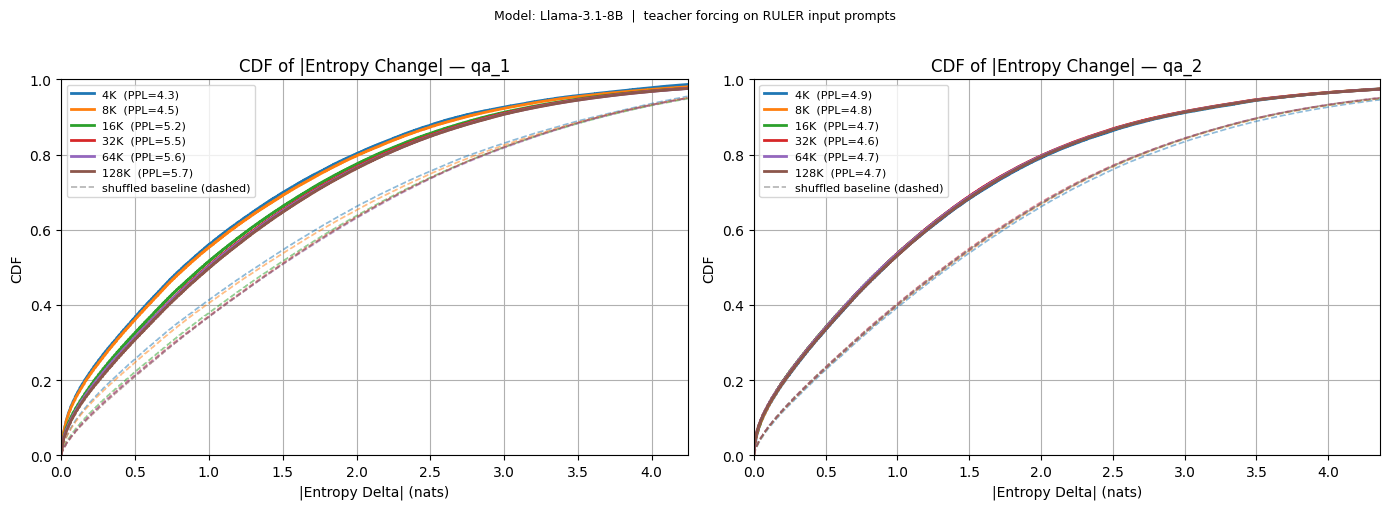

In [20]:
# COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
COLORS = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown']


from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, task in zip(axes, TASKS):
    # Compute shared x-axis limit from all shuffled baselines in this subplot
    all_shuf = [results[task][l][1] for l in LENGTHS if l in results[task]]
    xmax = float(np.quantile(np.concatenate(all_shuf), 0.95)) if all_shuf else 2.0

    for i, length in enumerate(LENGTHS):
        if length not in results[task]:
            continue
        abs1, abs_shuf, ppl = results[task][length]
        color = COLORS[i]
        label = f'{length // 1024}K  (PPL={ppl:.1f})'

        xx, yy = ecdf(abs1)
        xs, ys = ecdf(abs_shuf)

        ax.plot(xx, yy, color=color, linewidth=2,   label=label)
        ax.plot(xs, ys, color=color, linewidth=1.2, linestyle='--', alpha=0.5)

    # Add a single legend entry explaining the dashed style
    handles, labels = ax.get_legend_handles_labels()
    handles.append(Line2D([0], [0], color='gray', linewidth=1.2, linestyle='--', alpha=0.6))
    labels.append('shuffled baseline (dashed)')
    ax.legend(handles=handles, labels=labels, fontsize=8)

    ax.set_xlim(0, xmax)
    ax.set_ylim(0, 1)
    ax.set_xlabel('|Entropy Delta| (nats)')
    ax.set_ylabel('CDF')
    ax.set_title(f'CDF of |Entropy Change| — {task}')

plt.suptitle(f'Model: {MODEL_NAME.split("/")[-1]}  |  teacher forcing on RULER input prompts', fontsize=9, y=1.01)
plt.tight_layout()
SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(SAVE_PATH, dpi=150, bbox_inches='tight')
print(f'Saved to {SAVE_PATH}')
plt.show()